In [1]:
# 6.6 Q3 - Retail Product Purchase Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
    classification_report, roc_curve, auc)

In [3]:
df = pd.read_csv('datasets/retail_product_prediction.csv')
print("Shape:", df.shape)
print(df.head())
print()
print("Class distribution:")
print(df['will_purchase'].value_counts())

Shape: (500, 11)
   age    income  days_since_last_purchase  total_past_purchases  \
0   63   87085.0                       206                    22   
1   20   58716.0                        56                     6   
2   46   92949.0                       256                    16   
3   52   84687.0                       345                    27   
4   56  116914.0                       275                    19   

   avg_order_value  browsing_time_minutes  cart_abandonment_rate  \
0            58.77                   11.4                   0.68   
1           131.23                    7.9                   0.18   
2           152.88                    3.5                   0.63   
3           185.24                    2.6                   0.15   
4           368.57                    7.0                   0.53   

   product_category_views  email_opens  membership_years  will_purchase  
0                       8           23               2.7              1  
1                

In [4]:
print("Null values:")
print(df.isnull().sum())

Null values:
age                         0
income                      0
days_since_last_purchase    0
total_past_purchases        0
avg_order_value             0
browsing_time_minutes       0
cart_abandonment_rate       0
product_category_views      0
email_opens                 0
membership_years            0
will_purchase               0
dtype: int64


In [5]:
y = df['will_purchase']
X = df.drop(columns=['will_purchase'])
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (500, 10) y shape: (500,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (350, 10) Test: (150, 10)


In [7]:
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)

model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
}).sort_values('Coefficient', ascending=False, key=abs)
print(coef_df)

                    Feature  Coefficient
5     browsing_time_minutes     1.231651
1                    income     0.713018
3      total_past_purchases     0.616375
6     cart_abandonment_rate    -0.500785
4           avg_order_value     0.412768
7    product_category_views     0.359620
9          membership_years     0.325621
8               email_opens     0.311855
2  days_since_last_purchase    -0.278237
0                       age    -0.029058


In [8]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[  9  21]
 [  3 117]]
Accuracy: 0.84

              precision    recall  f1-score   support

           0       0.75      0.30      0.43        30
           1       0.85      0.97      0.91       120

    accuracy                           0.84       150
   macro avg       0.80      0.64      0.67       150
weighted avg       0.83      0.84      0.81       150



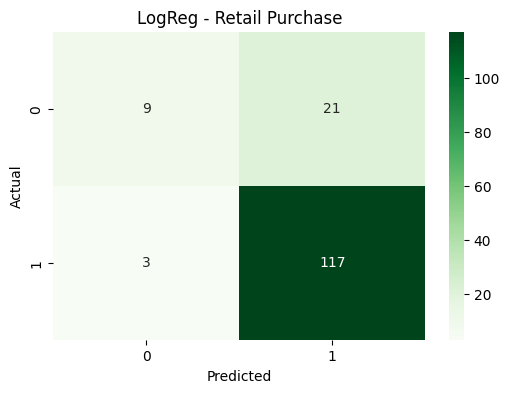

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LogReg - Retail Purchase')
plt.show()

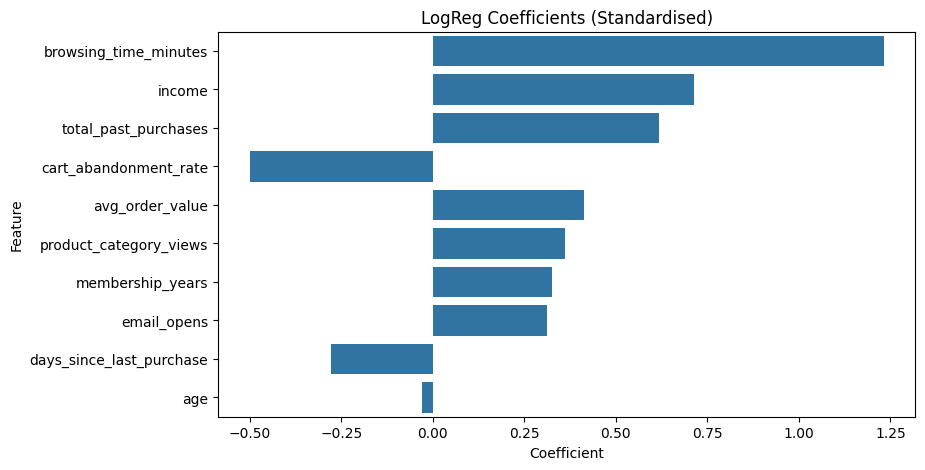

In [10]:
plt.figure(figsize=(9, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('LogReg Coefficients (Standardised)')
plt.show()